# Solutions to Process 7
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$.

Try including the edge radiation in the PPB; don't only consider the core radiation. Also investigate Hanni's 0.6 factor for core radiation.

In [ ]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set up
Same as in `solutions_to_process_2.ipynb`.

## Edge rad experiment
i_rad_loss = 0 always. Makes PPB valid as considers edge radiation too.

Tried to solve: get model error in power.py. Need to re-solve the optimisation problem. failure_uq repo, find_sol.ipynb. Ran with `i_rad_loss = 0`, try to find optimised solution: fails to solve. Drop pnetelin from 400, try again: solves. Largest value solves for: 200 MW.

Compare `i_rad_loss` 1 (core) and 0 (core and edge) optimised solutions: both run with my modifications so far.

Then try with Hanni's coreradiationfraction = 0.6 set to 1.0 (set in input file).

In [15]:
runs_metadata = [
    RunMetadata("lt_irad_1_pnet_200_MFILE.DAT", "irad1: core only"),
    RunMetadata("lt_irad_0_pnet_200_MFILE.DAT", "irad0: core and edge"),
    RunMetadata(
        "lt_irad_0_pnet_200_coreradfrac_MFILE.DAT",
        "irad0: core and edge, coreradfrac=1.0",
    ),
]

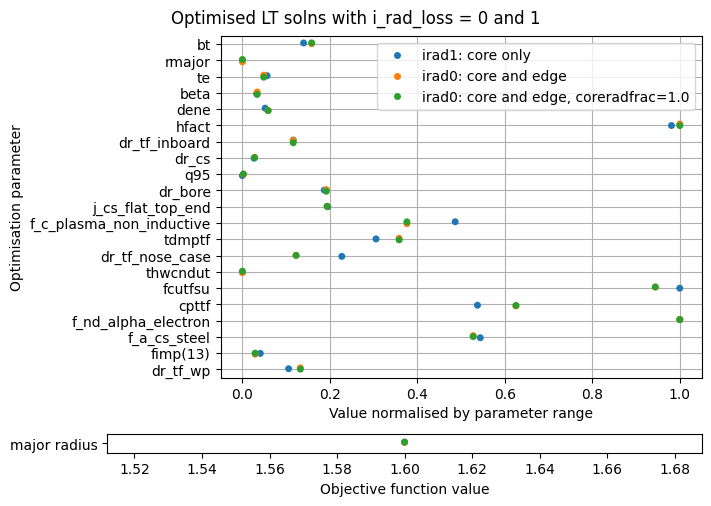

In [16]:
fig, df = plot_mfile_solutions(
    runs_metadata,
    "Optimised LT solns with i_rad_loss = 0 and 1",
    normalisation_type="range",
)

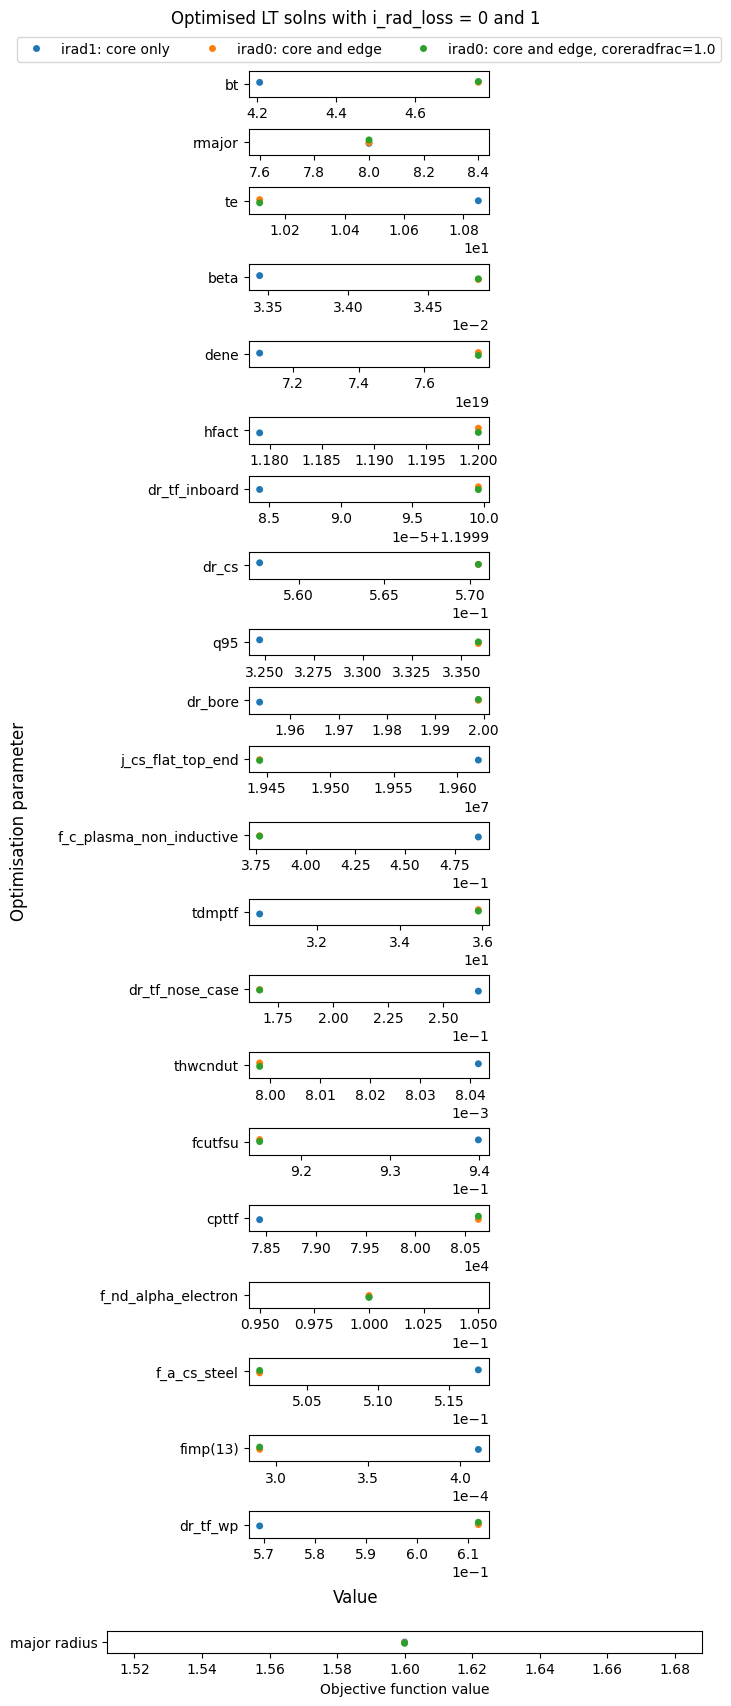

In [17]:
fig, df = plot_mfile_solutions(
    runs_metadata,
    "Optimised LT solns with i_rad_loss = 0 and 1",
    normalisation_type=None,
)

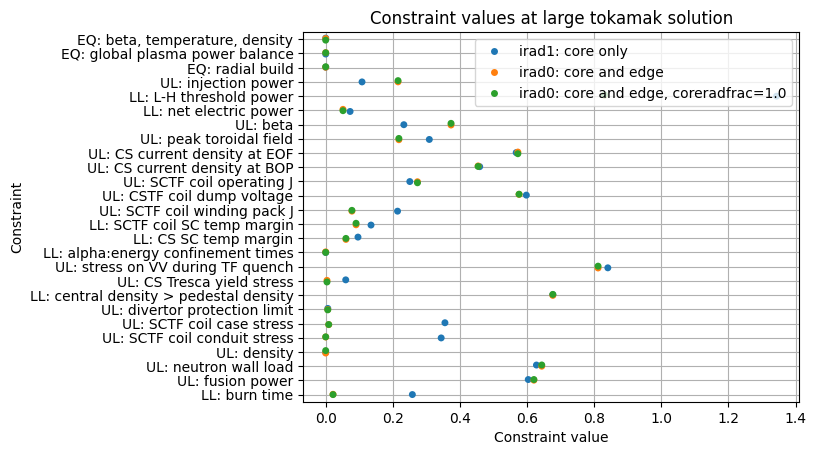

In [18]:
fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Constraint values at large tokamak solution",
)